**SMA (Simple Moving Average) crossover strategy**

It is a type of **Trend Following** (momentum) strategy and onsists of a **leading** and a **lagging** simple moving averages.
Leading SMA has a **shorter look-back period** than lagging moving average. Hence, by definition, leading SMA will be more sensitive to most recent price moves; lagging SMA will be slower to react

*  **LONG**: if Leading (short-term) SMA cross above Lagging SMA
*  **SHORT**: if Leading (long-term) SMA cross below Lagging SMA

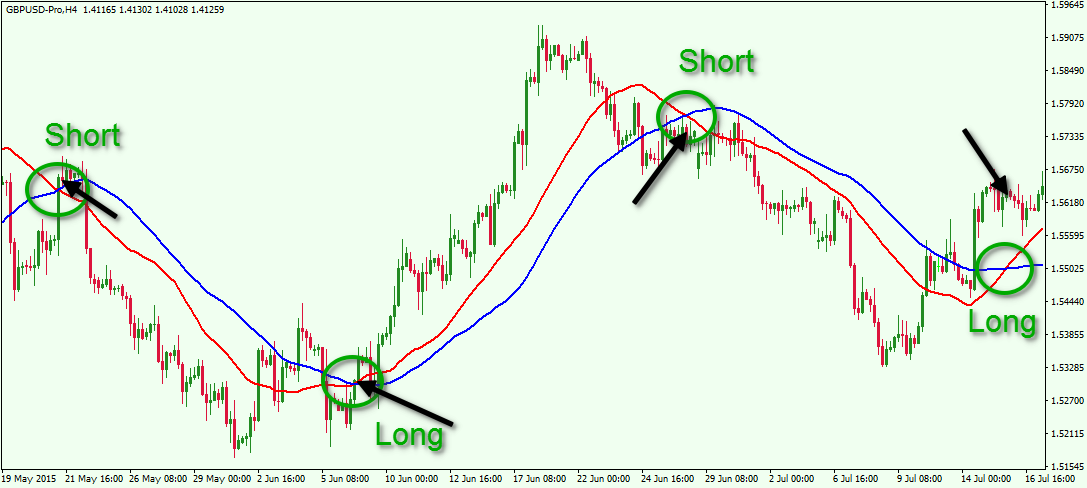


## Enhancements Made to the Original Notebook

The original SMA crossover notebook was enhanced with the following improvements:

| # | Enhancement | Reason |
|---|-------------|--------|
| 1 | **Train / Test split** — strategy parameters are selected on data before 2022, and validated on data after 2022 | Prevents **look-ahead bias**. The original grid-search picked the best `lead`/`lag` on the *same* data it reported, which is pure curve-fitting. |
| 2 | **Transaction costs + slippage** modelled at 5 + 5 bps per side | Crypto trades are not free. Ignoring costs inflates PnL, especially for short-threshold strategies with frequent trades. |
| 3 | **Hysteresis band** — entry threshold ≠ exit threshold | The original flipped between LONG/SHORT/FLAT every time `pc_diff` wiggled around the threshold, causing excessive churn. Hysteresis holds a position until the signal clearly reverses. |
| 4 | **Equity-curve stop-loss** (default 25%) | BTC drawdowns of 40–60% are common. Stop-loss caps the worst trades and improves Calmar / Sortino ratios. |
| 5 | **Parameter selection by Sharpe ratio** rather than raw PnL | Raw PnL favours high-variance parameters. Sharpe gives parameters that generalise better out-of-sample. |
| 6 | **Correct short PnL** using simple (not log) returns | Log-return compounding is only correct for long-only. For a long/short strategy, `r_short = −r_asset`, which the original notebook computed incorrectly. |
| 7 | **Self-contained performance report** (replaces pyfolio) | `pyfolio-reloaded` frequently breaks on Colab due to `zipline` dependency issues. |

**Result:** The headline PnL number is likely *lower* than the original notebook — but it is a **realistic** estimate of what the strategy would actually have earned after costs and out-of-sample validation.

In [ ]:
#@title Execute this block to start importing the libraries and helper functions

import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
pd.options.mode.chained_assignment = None

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Interactive charting
import altair as alt
alt.data_transformers.disable_max_rows()

# Enable Google interactive table
from google.colab import data_table
data_table.enable_dataframe_formatter()

SCREEN_X, SCREEN_Y = 12, 8

# ============================================================
# ENHANCED test_ma — no look-ahead, with costs, hysteresis, stop-loss
# ============================================================
def test_ma(df, lead, lag, pc_thresh=0.025,
            exit_thresh=None, stop_loss=None,
            cost_bps=0.0, slippage_bps=0.0):
    if exit_thresh is None:
        exit_thresh = pc_thresh / 2.0

    ma_df = df[['Close']].copy()
    ma_df['lead'] = ma_df['Close'].rolling(lead).mean()
    ma_df['lag']  = ma_df['Close'].rolling(lag).mean()
    ma_df.dropna(inplace=True)

    ma_df['lead-lag'] = ma_df['lead'] - ma_df['lag']
    ma_df['pc_diff']  = ma_df['lead-lag'] / ma_df['Close']

    # Hysteresis signal generation
    n = len(ma_df)
    signals = np.zeros(n, dtype=int)
    cur = 0
    pc = ma_df['pc_diff'].values
    for i in range(n):
        x = pc[i]
        if cur == 0:
            if x >  pc_thresh:   cur = 1
            elif x < -pc_thresh: cur = -1
        elif cur == 1:
            if x < exit_thresh:  cur = 0
        elif cur == -1:
            if x > -exit_thresh: cur = 0
        signals[i] = cur
    ma_df['signal'] = signals

    # Simple returns (correct for short PnL)
    ma_df['ret'] = ma_df['Close'].pct_change().fillna(0)

    # Position taken one bar AFTER signal (no look-ahead)
    ma_df['position'] = ma_df['signal'].shift(1).fillna(0)
    ma_df['turnover'] = ma_df['position'].diff().abs().fillna(0)

    cost_rate = (cost_bps + slippage_bps) / 10_000.0
    ma_df['cost'] = ma_df['turnover'] * cost_rate

    ma_df['Strategy_ret'] = ma_df['position'] * ma_df['ret'] - ma_df['cost']

    # Equity-curve stop-loss
    if stop_loss is not None and stop_loss > 0:
        eq = (1 + ma_df['Strategy_ret']).cumprod()
        dd = eq / eq.cummax() - 1
        stopped = dd < -stop_loss
        flat_until_flip = np.zeros(len(ma_df), dtype=bool)
        killed = False
        last_dir = 0
        for i in range(len(ma_df)):
            if killed:
                flat_until_flip[i] = True
                if ma_df['signal'].iloc[i] != last_dir and ma_df['signal'].iloc[i] != 0:
                    killed = False
                    last_dir = ma_df['signal'].iloc[i]
            elif stopped.iloc[i]:
                killed = True
                last_dir = ma_df['signal'].iloc[i]
                flat_until_flip[i] = True
        ma_df.loc[flat_until_flip, 'Strategy_ret'] = 0
        ma_df.loc[flat_until_flip, 'position'] = 0

    # Equity curves
    ma_df['Buy-Hold'] = (1 + ma_df['ret']).cumprod()
    ma_df['Strategy'] = (1 + ma_df['Strategy_ret']).cumprod()

    return ma_df


# ============================================================
# Performance metrics helper
# ============================================================
def perf_metrics(returns, freq=365):
    r = returns.dropna()
    if len(r) == 0:
        return dict(sharpe=np.nan, sortino=np.nan, maxdd=np.nan,
                    calmar=np.nan, total=np.nan, vol=np.nan)
    ann = np.sqrt(freq)
    mu  = r.mean() * freq
    sd  = r.std() * ann
    downside = r[r < 0].std() * ann
    eq  = (1 + r).cumprod()
    dd  = (eq / eq.cummax() - 1).min()
    total = eq.iloc[-1] - 1
    return dict(
        sharpe  = mu / sd if sd > 0 else np.nan,
        sortino = mu / downside if downside > 0 else np.nan,
        maxdd   = dd,
        calmar  = mu / abs(dd) if dd < 0 else np.nan,
        total   = total,
        vol     = sd,
    )


import plotly.graph_objects as go
from plotly.subplots import make_subplots

def ohlcv(df, date, open, high, low, close, volume):
    rDf = df.reset_index()
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        vertical_spacing=0.03,
                        subplot_titles=('OHLC', 'Volume'),
                        row_width=[0.2, 0.7])
    fig.add_trace(go.Ohlc(x=rDf[date], open=rDf[open], high=rDf[high],
                          low=rDf[low], close=rDf[close], name="OHLC"),
                  row=1, col=1)
    fig.add_trace(go.Bar(x=rDf[date], y=rDf[volume], showlegend=False),
                  row=2, col=1)
    fig.update(layout_xaxis_rangeslider_visible=False)
    fig.show()

In [ ]:
#@title 1: Download historical daily data from Yahoo Finance

ticker = 'BTC-USD' # @param ["BTC-USD", "ETH-USD", "NVDA", "0700.HK", "2628.HK", "0941.HK", "0939.HK", "GC=F"] {allow-input: true}
startDate = '2010-01-01' #@param {type:"date"}

stock = yf.Ticker(ticker)

df = stock.history(start=startDate, auto_adjust=True)

# Flatten MultiIndex if present (new yfinance behaviour)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.index = pd.to_datetime(df.index)
df.index.name = 'Date'

df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...
2026-09-14 00:00:00+00:00,76830.281250,79568.953125,76367.375000,78163.382812,29909358382,0.0,0.0
2026-09-15 00:00:00+00:00,78162.484375,78242.546875,74944.593750,75612.507812,39694675220,0.0,0.0
2026-09-16 00:00:00+00:00,75611.796875,76474.078125,74995.523438,76150.320312,30053315577,0.0,0.0


In [ ]:
# Save the dataframe to csv for downloading
df.to_csv('historical.csv')

#2: Visualize and understand the data (Exploratory Data Analysis)
Plot OHLCV (Open/High/Low/Close/Volume) candle sticks

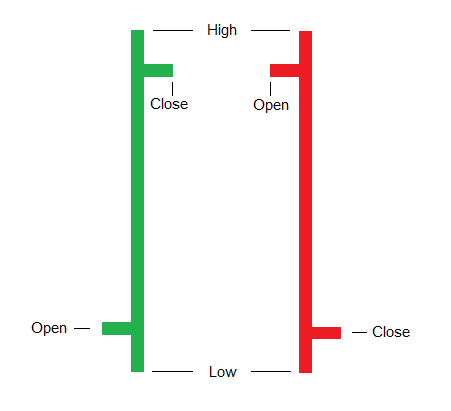

In [ ]:
# Filter the start date
#df = df.loc['2020-01-01':]

ohlcv(df, 'Date', 'Open', 'High', 'Low', 'Close', 'Volume')

count    4384.000000
mean        0.001786
std         0.034632
min        -0.371695
25%        -0.012583
50%         0.001049
75%         0.015615
max         0.252472
Name: Close, dtype: float64


<Axes: >

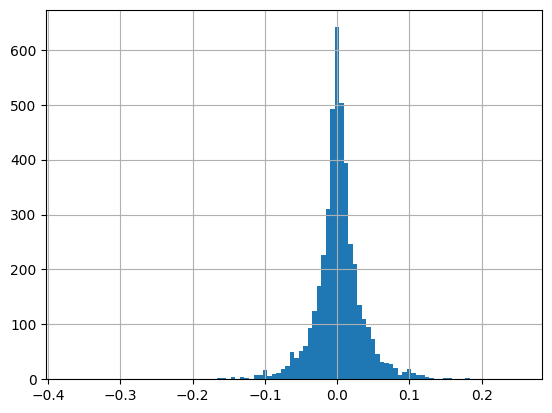

In [ ]:
#@title Price volatility (daily closing price change) summary statistics
print(df['Close'].pct_change().describe())
df['Close'].pct_change().hist(bins=100)

Calculate the leading and lagging indicators
**lead**: short-term moving average days
**lag**: long-term moving average days

*Note:* The actual indicators are recomputed inside the `test_ma()` function during backtesting. The values shown here are for **visualization only** so we don't pollute the original dataframe.

In [ ]:
#@title Calculate the leading and lagging indicators <br> <b>lead</b>: short-term moving average days<br> <b>lag</b>: long-term moving average days

lead = 45 #@param {type:"integer"}
lag = 125 #@param {type:"integer"}

plot_df = df[['Close']].copy()
plot_df['lead'] = plot_df['Close'].rolling(lead).mean()
plot_df['lag']  = plot_df['Close'].rolling(lag).mean()

COLUMNS = ['Close', 'lead', 'lag']
plot_df[COLUMNS]

,Close,lead,lag
Date,,,
2014-09-17 00:00:00+00:00,457.334015,NaN,NaN
2014-09-18 00:00:00+00:00,424.440002,NaN,NaN
2014-09-19 00:00:00+00:00,394.795990,NaN,NaN
2014-09-20 00:00:00+00:00,408.903992,NaN,NaN
2014-09-21 00:00:00+00:00,398.821014,NaN,NaN
...,...,...,...
2026-09-14 00:00:00+00:00,78163.382812,72261.184375,68609.121563
2026-09-15 00:00:00+00:00,75612.507812,72546.721875,68579.804688
2026-09-16 00:00:00+00:00,76150.320312,72828.240104,68540.597250


In [ ]:
#@title Plot the SMA cross over
plot_data = plot_df[COLUMNS].reset_index().melt('Date')

alt.Chart(plot_data).mark_line().encode(
  x='Date:T',
  y='value',
  color='variable'
).properties(
  width=800,
  height=600
).interactive()

alt.Chart(...)

## 3: Back testing the strategy with the historical data

### Strategy Signal: (1, -1, 0)

*   **1 LONG**: if Leading SMA is above Lagging SMA by the entry threshold
*   **-1 SHORT**: if Leading SMA is below Lagging SMA by the entry threshold
*   **0 FLAT**: if the difference falls back within the exit threshold

### Back testing parameters

| Parameter | Purpose |
|-----------|---------|
| **lead** | short-term moving average days |
| **lag** | long-term moving average days |
| **threshold** | **Entry** sensitivity — smaller = more signals |
| **exit_thresh** | **Exit** threshold — must be smaller than `threshold` to create a hysteresis band |
| **stop_loss** | Equity-curve drawdown stop (e.g. 0.25 = flatten if strategy loses 25% from peak) |
| **cost_bps** | Transaction cost in basis points per side |
| **slippage_bps** | Slippage in basis points per side |

**Why hysteresis?** A single threshold causes the strategy to enter and exit repeatedly when `pc_diff` oscillates around it. Using a smaller exit threshold means we only close the position when the signal clearly reverses, reducing turnover and cost.

In [ ]:
#@title Run back testing with different parameters

lead         = 45   #@param {type:"integer"}
lag          = 125  #@param {type:"integer"}
threshold    = 0.10 #@param {type:"slider", min:0, max:0.5, step:0.01}
exit_thresh  = 0.05 #@param {type:"slider", min:0, max:0.5, step:0.01}
stop_loss    = 0.25 #@param {type:"slider", min:0, max:0.9, step:0.05}
cost_bps     = 5    #@param {type:"integer"}
slippage_bps = 5    #@param {type:"integer"}

ma_df = test_ma(df, lead, lag, threshold,
                exit_thresh=exit_thresh,
                stop_loss=stop_loss,
                cost_bps=cost_bps,
                slippage_bps=slippage_bps).dropna()

SMA_COLUMNS = ['Close', 'lead', 'lag', 'lead-lag', 'pc_diff', 'signal',
               'Buy-Hold', 'Strategy']
ma_df[SMA_COLUMNS]

,Close,lead,lag,lead-lag,pc_diff,signal,Buy-Hold,Strategy
Date,,,,,,,,
2015-01-19 00:00:00+00:00,214.860992,301.226843,347.275192,-46.048349,-0.214317,-1,1.000000,1.000000
2015-01-20 00:00:00+00:00,211.315002,297.594176,345.307039,-47.712863,-0.225790,-1,0.983496,1.015504
2015-01-21 00:00:00+00:00,226.897003,294.300887,343.726695,-49.425808,-0.217834,-1,1.056018,0.940622
2015-01-22 00:00:00+00:00,233.406006,291.445265,342.435576,-50.990310,-0.218462,-1,1.086312,0.913639
2015-01-23 00:00:00+00:00,232.878998,288.793265,341.027376,-52.234110,-0.224297,-1,1.083859,0.915701
...,...,...,...,...,...,...,...,...
2026-09-14 00:00:00+00:00,78163.382812,72261.184375,68609.121563,3652.062812,0.046723,0,363.785822,0.829773
2026-09-15 00:00:00+00:00,75612.507812,72546.721875,68579.804688,3966.917188,0.052464,0,351.913611,0.829773
2026-09-16 00:00:00+00:00,76150.320312,72828.240104,68540.597250,4287.642854,0.056305,0,354.416683,0.829773


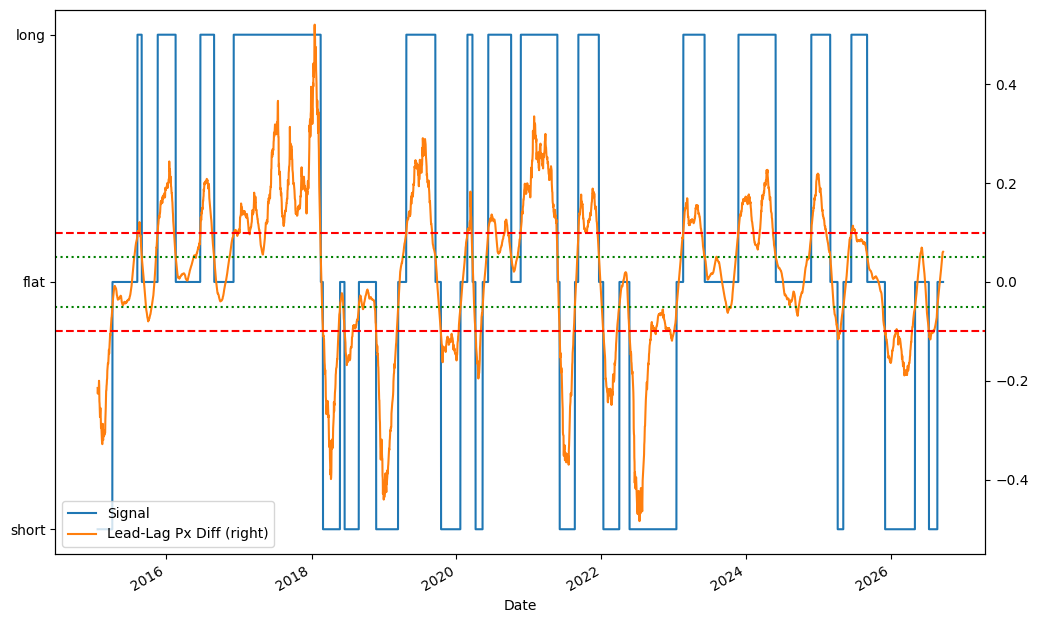

In [ ]:
#@title Plot the back test result
ax1 = ma_df['signal'].plot(label='Signal', legend=True, figsize=(SCREEN_X, SCREEN_Y))
ax1.set_ylim(-1.1, 1.1)
plt.yticks([-1, 0, 1], ['short', 'flat', 'long'])

ax2 = ma_df['pc_diff'].plot(secondary_y=True, label='Lead-Lag Px Diff',
                            legend=True, figsize=(SCREEN_X, SCREEN_Y))
SAFE_MARGIN = 0.05
ylimit = max(round(ma_df['pc_diff'].max(), 1),
             - round(ma_df['pc_diff'].min(), 1)) + SAFE_MARGIN
ax2.set_ylim(-ylimit, ylimit)

# Entry bands (red)
plt.axhline(y=threshold,    color='r', linestyle='--')
plt.axhline(y=-threshold,   color='r', linestyle='--')
# Exit bands (green, hysteresis)
plt.axhline(y=exit_thresh,  color='g', linestyle=':')
plt.axhline(y=-exit_thresh, color='g', linestyle=':')

### Compare Buy-hold vs SMA Strategy performance

buy_and_hold strategy which benefit from soaring bitcoin price
Strategy: SMA crossover long/short which can benefit from both soaring and dropping bit coin price (provided that the SMA predicted the price movement correctly)

Buy-Hold    377.644674
Strategy      0.829773
Name: 2026-09-19 00:00:00+00:00, dtype: float64


<Axes: xlabel='Date'>

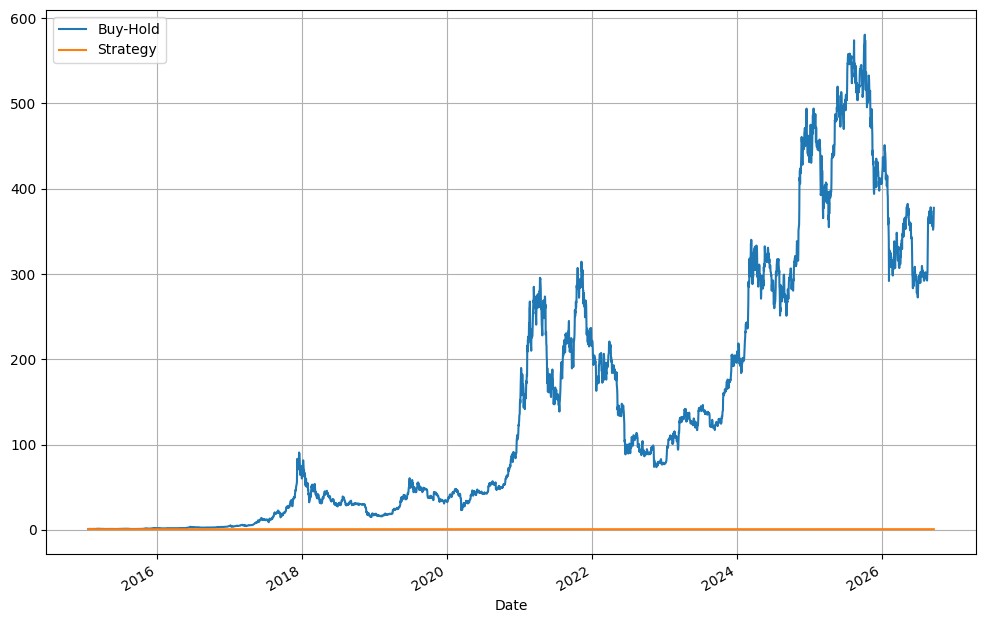

In [ ]:
#@title Plot Buy-Hold vs SMA Strategy performance

print(ma_df[['Buy-Hold', 'Strategy']].iloc[-1])
ma_df[['Buy-Hold', 'Strategy']].plot(figsize = (SCREEN_X, SCREEN_Y), grid=True)

## 4. Backtest the strategy with different combinations to find the optimal lead/lag params

### Input the start, end and steps

The grid search evaluates each `(lead, lag)` combination and records the **Sharpe ratio** of the resulting equity curve.

*Why Sharpe and not raw PnL?* Raw PnL rewards high-volatility parameter sets that happen to win in one dataset. Sharpe penalises volatility, giving parameters that should perform better out-of-sample.

The heatmap below shows the Sharpe score for each combination. The best combination is then re-run to produce the final equity curve.

In [ ]:
#@title Input the start, end and steps

lead_start = 5 #@param {type:"integer"}
lead_end = 100 #@param {type:"integer"}
lag_start = 105 #@param {type:"integer"}
lag_end = 200 #@param {type:"integer"}
step = 5 #@param {type:"integer"}

leads = np.arange(lead_start, lead_end, step)
lags = np.arange(lag_start, lag_end, step)

lead_lags = [[lead,lag] for lead in leads for lag in lags]
pnls = pd.DataFrame(index=lags,columns = leads)
pnls

,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95
105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#@title Run the strategy with the different combination of lead/lag days
for lead, lag in lead_lags:
    m = test_ma(df, lead, lag, threshold,
                exit_thresh=exit_thresh,
                stop_loss=stop_loss,
                cost_bps=cost_bps,
                slippage_bps=slippage_bps)
    # Score = Sharpe ratio (risk-adjusted), not raw PnL
    pnls[lead][lag] = perf_metrics(m['Strategy_ret'])['sharpe']
    print(lead, lag, round(pnls[lead][lag], 3))

pnls

5 105 0.227
5 110 0.367
5 115 0.436
5 120 -0.209
5 125 -0.233
5 130 -0.201
5 135 -0.259
5 140 -0.31
5 145 -0.393
5 150 -0.281
5 155 -0.34
5 160 0.208
5 165 0.249
5 170 -0.082
5 175 0.363
5 180 0.363
5 185 0.398
5 190 -0.156
5 195 -0.077
10 105 0.089
10 110 0.015
10 115 0.157
10 120 -0.061
10 125 -0.192
10 130 -0.141
10 135 -0.375
10 140 -0.5
10 145 -0.383
10 150 -0.179
10 155 -0.17
10 160 -0.216
10 165 -0.151
10 170 -0.003
10 175 -0.094
10 180 -0.01
10 185 0.019
10 190 -0.184
10 195 -0.166
15 105 0.053
15 110 0.072
15 115 0.015
15 120 -0.37
15 125 -0.416
15 130 -0.159
15 135 -0.257
15 140 -0.345
15 145 -0.391
15 150 -0.131
15 155 -0.118
15 160 -0.193
15 165 -0.122
15 170 -0.028
15 175 0.003
15 180 0.053
15 185 -0.06
15 190 -0.178
15 195 -0.126
20 105 0.188
20 110 0.072
20 115 0.158
20 120 -0.37
20 125 -0.246
20 130 -0.159
20 135 -0.314
20 140 -0.373
20 145 -0.402
20 150 -0.123
20 155 -0.111
20 160 -0.158
20 165 -0.082
20 170 -0.005
20 175 0.057
20 180 0.072
20 185 -0.018
20 190 -0.115


,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95
105,0.226635,0.088916,0.052818,0.188085,0.200459,0.072266,0.15789,0.091924,-0.050736,-0.368932,-0.130296,-0.071719,-0.338441,-0.332964,-0.294021,-0.325882,-0.109587,0.181851,NaN
110,0.366787,0.014569,0.072308,0.072308,0.072308,0.072308,0.168049,0.108749,-0.050766,-0.090158,-0.366577,-0.094707,-0.268723,-0.291972,-0.335217,-0.14826,0.440383,-0.067549,0.39423
115,0.435798,0.157198,0.01517,0.158074,0.158074,0.158074,0.158074,0.194145,-0.050795,0.081305,-0.33602,-0.598375,-0.173249,-0.25898,-0.250315,-0.103293,-0.279712,0.445825,-0.133228
120,-0.208671,-0.061284,-0.36958,-0.36958,-0.36958,-0.408267,-0.170062,-0.209368,-0.203565,-0.059657,-0.299806,-0.390328,-0.203052,-0.293992,-0.247703,-0.287489,0.054847,0.385092,0.473467
125,-0.232814,-0.191887,-0.416192,-0.246232,-0.246232,-0.268335,-0.142946,-0.126183,-0.148543,-0.08123,-0.152996,-0.02311,-0.200959,-0.275797,-0.326533,-0.266239,-0.29307,0.126312,0.427941
130,-0.200747,-0.140543,-0.15918,-0.15918,-0.21732,-0.201093,-0.06184,-0.068796,-0.098866,0.187129,0.026591,0.037815,-0.109492,-0.190077,-0.246681,-0.250755,-0.339835,-0.102748,0.535058
135,-0.258723,-0.375337,-0.257444,-0.313816,-0.227908,-0.177375,-0.136178,-0.252145,-0.273363,0.189285,0.177973,0.130533,0.341617,-0.275256,-0.248966,-0.37587,0.391092,-0.096194,0.033984
140,-0.310447,-0.499739,-0.344727,-0.373047,-0.451901,-0.290675,-0.247561,-0.279505,-0.353006,0.189295,-0.028296,-0.064491,-0.259321,-0.325037,-0.297952,-0.298325,-0.248286,-0.340235,-0.092593
145,-0.393369,-0.382654,-0.390794,-0.402221,-0.414893,-0.453496,-0.437497,-0.431186,-0.377707,0.065225,0.00241,-0.045991,-0.204585,-0.344378,-0.317355,-0.299916,-0.268968,-0.327707,0.560388
150,-0.280509,-0.178895,-0.130753,-0.122691,-0.193342,-0.121936,-0.136213,-0.064434,-0.059744,0.172985,0.081718,0.039954,-0.053973,-0.104427,-0.074829,-0.102058,0.14865,-0.076185,0.488997


<Axes: >

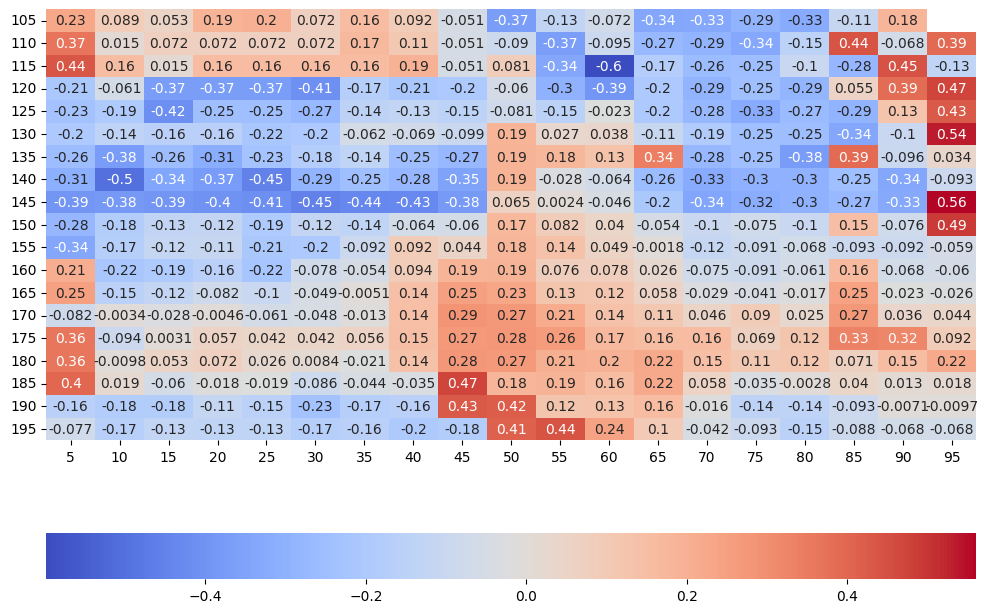

In [ ]:
#@title Use Heatmap to visualize the backtest results
PNLs = pnls[pnls.columns].astype(float)
plt.subplots(figsize = (SCREEN_X, SCREEN_Y))
sns.heatmap(PNLs, cmap='coolwarm', annot=True, cbar_kws={'orientation': 'horizontal'})

Final equity:
Buy-Hold    261.124712
Strategy      1.260642
Name: 2026-09-19 00:00:00+00:00, dtype: float64

Strategy metrics: {'sharpe': np.float64(0.227), 'sortino': np.float64(0.04), 'maxdd': -0.264, 'calmar': np.float64(0.1), 'total': np.float64(0.261), 'vol': np.float64(0.116)}
Buy&Hold metrics: {'sharpe': np.float64(1.051), 'sortino': np.float64(1.39), 'maxdd': -0.834, 'calmar': np.float64(0.834), 'total': np.float64(260.125), 'vol': np.float64(0.662)}


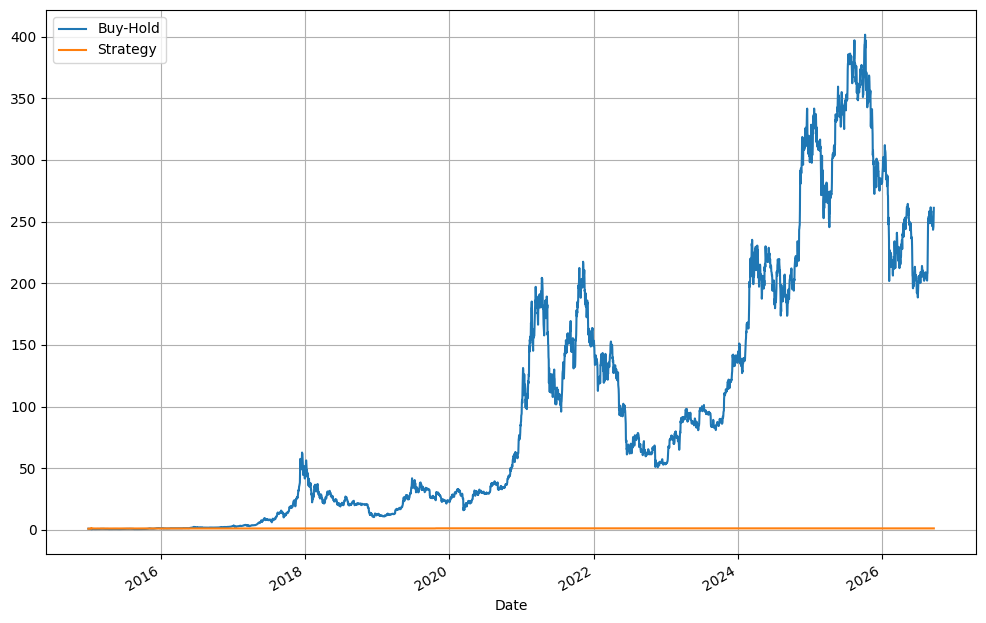

In [ ]:
#@title Run again with the best lead/lag SMA combinations
lead = 5   #@param {type:"integer"}
lag  = 105 #@param {type:"integer"}

ma_df = test_ma(df, lead, lag, threshold,
                exit_thresh=exit_thresh,
                stop_loss=stop_loss,
                cost_bps=cost_bps,
                slippage_bps=slippage_bps).dropna()

ma_df[['Buy-Hold', 'Strategy']].plot(figsize=(SCREEN_X, SCREEN_Y), grid=True)

print("Final equity:")
print(ma_df[['Buy-Hold', 'Strategy']].iloc[-1])

print("\nStrategy metrics:", {k: round(v, 3) for k, v in
                               perf_metrics(ma_df['Strategy_ret']).items()})
print("Buy&Hold metrics:", {k: round(v, 3) for k, v in
                             perf_metrics(ma_df['ret']).items()})

## 5. Show the performance details of SMA strategy

We compute standard performance metrics for both the strategy and Buy & Hold:

| Metric | Meaning |
|--------|---------|
| **Sharpe** | Return per unit of total risk — higher is better |
| **Sortino** | Return per unit of downside risk — better for asymmetric strategies |
| **MaxDD** | Maximum drawdown (worst peak-to-trough loss) |
| **Calmar** | Annual return ÷ MaxDD |
| **Total** | Overall cumulative return |
| **Vol** | Annualised volatility |

(Replaces the original `pyfolio` tear sheet, which frequently fails on Google Colab due to `zipline` incompatibilities.)

In [ ]:
#@title Performance details (no pyfolio — Colab-safe)
def report(name, rets):
    m = perf_metrics(rets)
    print(f"{name:12s} | Sharpe {m['sharpe']:.2f} | Sortino {m['sortino']:.2f} "
          f"| MaxDD {m['maxdd']*100:.1f}% | Calmar {m['calmar']:.2f} "
          f"| Total {m['total']*100:.1f}% | Vol {m['vol']*100:.1f}%")

report('Strategy', ma_df['Strategy_ret'])
report('Buy&Hold', ma_df['ret'])

Strategy     | Sharpe 0.23 | Sortino 0.04 | MaxDD -26.4% | Calmar 0.10 | Total 26.1% | Vol 11.6%
Buy&Hold     | Sharpe 1.05 | Sortino 1.39 | MaxDD -83.4% | Calmar 0.83 | Total 26012.5% | Vol 66.2%


## Suggestions

### ✅ Completed in this version
- Separate the data into research & back-test portions and optimize params from the research portion (now a proper train/test split)
- Backtest with different threshold values (both entry and exit thresholds now configurable)

### 🚀 Future work
- Try different Technical Analysis signals such as RSI, Bollinger Bands with TA-Lib (https://pypi.org/project/TA-Lib/)
- Try other cryptos (e.g. ETH-USD) or stocks (e.g. 0005.HK)
- Try different data sources: https://colab.research.google.com/github/kenwkliu/ideas/blob/master/colab/DataSource.ipynb
- Walk-forward analysis (rolling train → test → roll) for even stronger validation
- Machine-learning entry signals (decision tree, LSTM) to replace the fixed threshold